# ER Networks

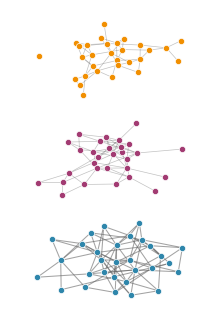

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.gridspec as gridspec

# ==================== 全局配置参数 ====================
# 网络参数
N_NODES = 30  # 节点数量
AVG_DEGREES = [3, 4, 6]  # 目标平均度

# 可视化参数
NODE_SIZE = 20  # 节点大小
NODE_LINEWIDTH = 0.5  # 节点边框宽度
EDGE_WIDTH = 0.5  # 边宽度
EDGE_ALPHA = 0.4  # 边透明度
SEED = 41  # 随机种子

# Nature Communication 风格配色

COLORS = ['#F18F01','#A23B72',  '#2E86AB' ]  # Nature风格的颜色
BG_COLOR = '#F8F9FA'  # 背景色

# ==================== 网络生成模块 ====================
def generate_er_network(n_nodes, avg_degree, seed):
    """生成ER随机网络"""
    np.random.seed(seed)
    # 计算连接概率
    p = avg_degree / (n_nodes - 1)
    
    # 生成邻接矩阵
    adj_matrix = np.random.rand(n_nodes, n_nodes) < p
    np.fill_diagonal(adj_matrix, False)  # 移除自环
    adj_matrix = np.triu(adj_matrix)  # 取上三角
    adj_matrix = adj_matrix | adj_matrix.T  # 对称化
    
    # 创建NetworkX图
    G = nx.Graph()
    G.add_nodes_from(range(n_nodes))
    
    for i in range(n_nodes):
        for j in range(i+1, n_nodes):
            if adj_matrix[i, j]:
                G.add_edge(i, j)
    
    return G

def get_natural_layout(G, seed):
    """生成符合Nature风格的布局（保持布局一致性）"""
    np.random.seed(seed)
    n_nodes = len(G.nodes())
    
    # 使用圆形布局作为基础
    pos = {}
    for i in range(n_nodes):
        angle = 2 * np.pi * i / n_nodes
        radius = 1.0 + np.random.uniform(-0.1, 0.1)
        angle_noise = angle + np.random.uniform(-0.1, 0.1)
        x = radius * np.cos(angle_noise)
        y = radius * np.sin(angle_noise)
        pos[i] = (x, y)
    
    # 使用spring布局进行优化，k值根据节点数调整
    k_value = 2.0 * np.sqrt(N_NODES / 40)  # 根据节点数调整斥力
    pos = nx.spring_layout(G, pos=pos, seed=seed, iterations=100, k=k_value)
    
    return pos

# ==================== 网络绘制模块 ====================
def draw_single_network(ax, G, pos, color, avg_degree):
    """绘制单个网络"""
    # 设置背景
#    ax.set_facecolor(BG_COLOR)
    
    # 计算实际平均度用于标题
    degrees = [d for _, d in G.degree()]
    actual_avg_degree = np.mean(degrees)
    
    # 根据平均度调整边的可视化参数，体现密度变化
    edge_width = EDGE_WIDTH
    edge_alpha = EDGE_ALPHA
    
    # 随着平均度增加，边更明显
    if avg_degree >= 5:
        edge_width = EDGE_WIDTH * 1.5
        edge_alpha = EDGE_ALPHA * 1.5
    
    # 先绘制边（在节点下面）
    nx.draw_networkx_edges(G, pos, ax=ax, 
                          alpha=edge_alpha, 
                          width=edge_width, 
                          edge_color='#666666')
    
    # 再绘制节点（在边上面）
    nx.draw_networkx_nodes(G, pos, ax=ax, 
                          node_color=color, 
                          node_size=NODE_SIZE, 
                          edgecolors='white', 
                          linewidths=NODE_LINEWIDTH)
    
    
    # 移除坐标轴
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    # 设置合适的显示范围
    all_x = [pos[i][0] for i in pos]
    all_y = [pos[i][1] for i in pos]
    
    x_min, x_max = min(all_x), max(all_x)
    y_min, y_max = min(all_y), max(all_y)
    
    # 添加边距（根据网络密度调整）
    density_factor = 1.0 + (avg_degree - 3) * 0.02  # 密度越高，边距越小
    x_margin = (x_max - x_min) * 0.2 / density_factor
    y_margin = (y_max - y_min) * 0.2 / density_factor
    
    ax.set_xlim(x_min - x_margin, x_max + x_margin)
    ax.set_ylim(y_min - y_margin, y_max + y_margin)
    
    return actual_avg_degree

# ==================== 主绘图函数 ====================
def create_er_networks_figure():
    """创建ER随机网络示意图（纵向排列）"""
    fig, axes = plt.subplots(3, 1, figsize=(2, 3))
    
    networks = []
    positions = []
    actual_degrees = []
    
    base_seed = SEED
    for i, avg_degree in enumerate(AVG_DEGREES):
        network_seed = base_seed + i * 100
        G = generate_er_network(N_NODES, avg_degree, network_seed)
        networks.append(G)
        layout_seed = network_seed
        pos = get_natural_layout(G, layout_seed)
        positions.append(pos)
    
    for i, (avg_degree, G, pos, color) in enumerate(zip(AVG_DEGREES, networks, positions, COLORS)):
        ax = axes[i]
        actual_degree = draw_single_network(ax, G, pos, color, avg_degree)
        actual_degrees.append(actual_degree)
        
    plt.tight_layout(pad=0.01, h_pad=0.01, w_pad=0.01)
    plt.savefig("ERTopology.svg")
    plt.show()
    
if __name__ == "__main__":
    create_er_networks_figure()
    
    

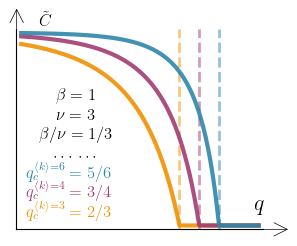

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
import matplotlib.gridspec as gridspec

# ==================== 全局配置参数 ====================
# Nature Communication 风格
plt.rcParams.update({
    'font.size': 24,
    'font.family': 'sans-serif',
    'text.usetex': True,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'legend.fontsize': 9,
})
# 配色方案 - Nature风格
#COLORS = ['#2E86AB', '#A23B72', '#F18F01']  # 蓝色、紫色、橙色
COLORS = ['#F18F01', '#A23B72', '#2E86AB']  # Square, Triangular, Hexagonal colors
BG_COLOR = '#F8F9FA'

# 网络参数
K_VALUES = [3, 4, 6]  # 平均度值

# ==================== 理论计算模块 ====================
def giant_component_size_theory(p, k):
    """
    使用生成函数方法计算ER网络中最大团簇的期望大小
    
    参数:
    p: 占据边的概率 (0到1之间)
    k: 网络平均度 ⟨k⟩
    
    返回:
    S: 最大团簇的相对大小 (0到1之间)
    u: 随机选择的边不连接到最大团簇的概率
    """
    # 自洽方程: u = exp(-k * (1 - u) * p)
    # 其中u是随机选择的边不连接到最大团簇的概率
    
    def equation(u):
        return u - np.exp(-k * (1 - u) * p)
    
    # 初始猜测：根据p值选择合适的初始值
    if p < 1/k:
        u_initial = 0.9  # 亚临界区域，u接近1
    else:
        u_initial = 0.1  # 超临界区域，u接近0
    
    try:
        # 求解自洽方程
        u_solution = fsolve(equation, u_initial, full_output=True)[0][0]
        
        # 确保解在合理范围内
        u_solution = np.clip(u_solution, 0, 1)
        
        # 最大团簇大小 S = 1 - exp(-k * (1 - u) * p)
        S = 1 - np.exp(-k * (1 - u_solution) * p)
        
        # 确保结果在合理范围内
        S = np.clip(S, 0, 1)
        
        return S, u_solution
    except:
        # 如果求解失败，返回0
        return 0.0, 1.0

def calculate_critical_point(k):
    """
    计算临界点 p_c
    对于ER网络，当 k*p = 1 时发生相变
    因此临界概率 p_c = 1/k
    """
    if k > 0:
        return 1.0 / k
    else:
        return 1.0

# ==================== 绘图函数 ====================
def plot_giant_component_phase_diagram():
    """
    绘制最大团簇大小S随占据概率p变化的相图
    只使用生成函数理论计算
    """
    # 创建图形
    fig, ax = plt.subplots(figsize=(3.5, 3))
    
    # 生成p的范围
    p_range = np.linspace(0, 1.0, 400)
    
    # 存储临界点信息
    critical_points = []
    
    # 对每个平均度值计算理论曲线
    for idx, k in enumerate(K_VALUES):
        S_values = []
        u_values = []
        
        # 计算临界点
        p_c = calculate_critical_point(k)
        critical_points.append((k, p_c))
        
        
        # 对每个p值计算理论S
        for p in p_range:
            S, u = giant_component_size_theory(p, k)
            S_values.append(S)
            u_values.append(u)
        
        # 转换为numpy数组
        S_array = np.array(S_values)
        
        # 绘制理论曲线
        line = ax.plot(1.0-p_range, S_array, color=COLORS[idx], 
                      linewidth=3.0, alpha=0.9,
                      label=f'$\\langle k \\rangle = {k}$',
                      zorder=3)
       

    # Set axis labels
    ax.set_xlabel('$q$', fontsize=16, loc='right', labelpad=-25)
    ax.set_ylabel('$\\tilde{C}$', fontsize=12, loc='top', labelpad=-25, rotation=0)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels("")
    ax.set_yticklabels("")
    
    # Hide top and right spines
    ax.spines['top'].set_visible(False) 
    ax.spines['right'].set_visible(False)
    
    # Add arrows
    # x-axis arrow
    ax.annotate('', xy=(1.1, -0.02), xycoords=('axes fraction', 'data'),
                xytext=(1.0, -0.02), textcoords=('axes fraction', 'data'),
                arrowprops=dict(arrowstyle='->', color='black', 
                lw=0.5, shrinkA=0, shrinkB=0))

    # y-axis arrow
    ax.annotate('', xy=(-0.019, 1.1), xycoords=('data', 'axes fraction'),
                xytext=(-0.019, 1.0), textcoords=('data', 'axes fraction'),
                arrowprops=dict(arrowstyle='->', color='black', 
                lw=0.5, shrinkA=0, shrinkB=0))

    # Add theoretical percolation threshold lines
    ax.axvline(x=1.0-1.0/3, color=COLORS[0], linestyle='--', alpha=0.5, linewidth=2)
    ax.axvline(x=1.0-1.0/4, color=COLORS[1], linestyle='--', alpha=0.5, linewidth=2)
    ax.axvline(x=1.0-1.0/6, color=COLORS[2], linestyle='--', alpha=0.5, linewidth=2)
    
    # Add theoretical value labels
    ft1 = 12
    ax.text(0.20, 0.05, r'$q_c^{\langle k \rangle =3} = 2/3$', color=COLORS[0], fontsize=ft1, ha='center', rotation=0, transform=ax.transData)
    ax.text(0.20, 0.15, r'$q_c^{\langle k \rangle =4} = 3/4$', color=COLORS[1], fontsize=ft1, ha='center', rotation=0, transform=ax.transData)
    ax.text(0.20, 0.25, r'$q_c^{\langle k \rangle =6} = 5/6$', color=COLORS[2], fontsize=ft1, ha='center', rotation=0, transform=ax.transData)
    ax.text(0.23, 0.65, '$\\beta = 1$',         color="black", fontsize=ft1, ha='center', rotation=0, transform=ax.transData)
    ax.text(0.23, 0.55, '$\\nu =   3$',         color="black", fontsize=ft1, ha='center', rotation=0, transform=ax.transData)
    ax.text(0.23, 0.45, '$\\beta/\\nu = 1/3$',  color="black", fontsize=ft1, ha='center', rotation=0, transform=ax.transData)
    ax.text(0.23, 0.35, '$\\cdots$ $\\cdots$',  color="black", fontsize=ft1, ha='center', rotation=0, transform=ax.transData)
   
    # 调整布局
    plt.tight_layout()
    plt.savefig("ERAttack.svg")
    plt.show()
    
    return 


# ==================== 主程序 ====================
if __name__ == "__main__":
        
    plot_giant_component_phase_diagram()
    
    
